In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

Esta celda para abrir los datos de TOL = 2.0

In [2]:
# URL del Google Sheet. Asegúrate de que la hoja esté compartida públicamente o con el email de tu cuenta Colab.
google_sheet_id = '1LuG-mVuB-33-kPug5oG5ZUH1EpTntQrYBpJhQXQlUC4'
google_sheet_url = f'https://docs.google.com/spreadsheets/d/{google_sheet_id}/export?format=xlsx'

# Carga el archivo Excel desde la URL en un DataFrame de pandas
df = pd.read_excel(google_sheet_url)

# Opcional: Muestra las primeras filas del DataFrame para verificar que se cargó correctamente.
print(df.head())

    N1  N2   N3  tol  width  height  Steps_to_Equilibrium      C_AA  C_AB  \
0  750   0  750    2     40      40                    16  0.456766   0.0   
1  750   0  750    2     40      40                    11  0.456944   0.0   
2  750   0  750    2     40      40                    11  0.458660   0.0   
3  750   0  750    2     40      40                    11  0.454189   0.0   
4  750   0  750    2     40      40                    11  0.457072   0.0   

       C_AC  C_BB  C_BC      C_CC  Unsat_A  Unsat_B  Unsat_C  
0  0.088608   0.0   0.0  0.454626       68        0       79  
1  0.084864   0.0   0.0  0.458192       68        0       65  
2  0.085709   0.0   0.0  0.455631       70        0       70  
3  0.089127   0.0   0.0  0.456684       82        0       72  
4  0.084432   0.0   0.0  0.458497       73        0       70  


Esta otra para abrir los datos de TOL = 0.0

In [3]:
# URL del Google Sheet. Asegúrate de que la hoja esté compartida públicamente o con el email de tu cuenta Colab.
google_sheet_id = '1yoq5U34E0sKERneZmEnf0CCnIN0ScLFIxdJzfpZik24'
google_sheet_url = f'https://docs.google.com/spreadsheets/d/{google_sheet_id}/export?format=xlsx'

# Carga el archivo Excel desde la URL en un DataFrame de pandas
df = pd.read_excel(google_sheet_url)

# Opcional: Muestra las primeras filas del DataFrame para verificar que se cargó correctamente.
print(df.head())

    N1  N2   N3  tol  width  height  Steps_to_Equilibrium      C_AA  C_AB  \
0  750   0  750    0     40      40                     9  0.459046   0.0   
1  750   0  750    0     40      40                    10  0.450900   0.0   
2  750   0  750    0     40      40                    11  0.459276   0.0   
3  750   0  750    0     40      40                    18  0.456506   0.0   
4  750   0  750    0     40      40                    10  0.452665   0.0   

       C_AC  C_BB  C_BC      C_CC  Unsat_A  Unsat_B  Unsat_C  
0  0.080306   0.0   0.0  0.460648      256        0      243  
1  0.097131   0.0   0.0  0.451969      298        0      296  
2  0.081269   0.0   0.0  0.459455      261        0      253  
3  0.086809   0.0   0.0  0.456684      262        0      269  
4  0.096096   0.0   0.0  0.451239      287        0      284  


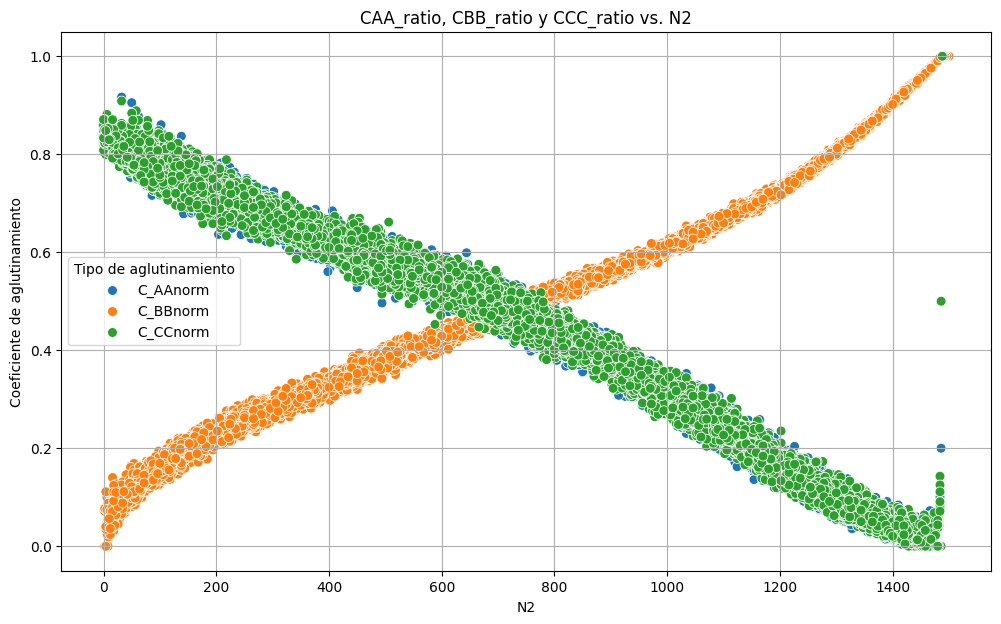

In [4]:
df['C_BBnorm'] = df['C_BB'] / (df['C_AB'] + df['C_BB'] + df['C_BC'])
df['C_AAnorm'] = df['C_AA'] / (df['C_AA'] + df['C_AB'] + df['C_AC'])
df['C_CCnorm'] = df['C_CC'] / (df['C_BC'] + df['C_CC'] + df['C_AC'])

plot_columns = ['C_AAnorm', 'C_BBnorm', 'C_CCnorm']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo_Mean', value_name='Valor_Mean')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor_Mean', hue='Tipo_Mean', data=df_melted, s=50)
plt.title('CAA_ratio, CBB_ratio y CCC_ratio vs. N2')
plt.xlabel('N2')
plt.ylabel('Coeficiente de aglutinamiento')
plt.grid(True)
plt.legend(title='Tipo de aglutinamiento')
plt.show()

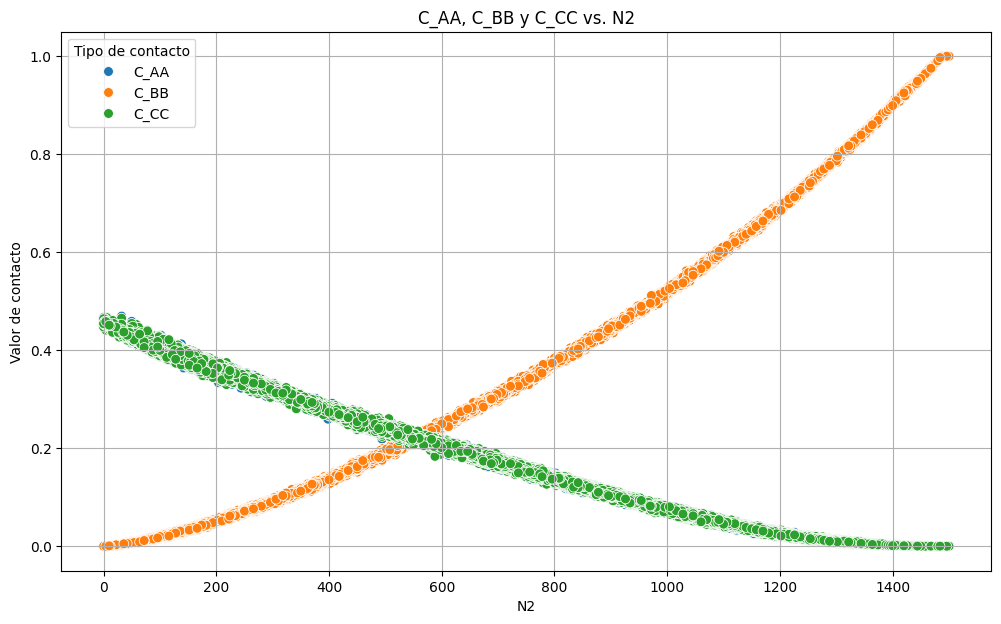

In [5]:
plot_columns = ['C_AA', 'C_BB', 'C_CC']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo_Mean', value_name='Valor_Mean')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor_Mean', hue='Tipo_Mean', data=df_melted, s=50)
plt.title('C_AA, C_BB y C_CC vs. N2')
plt.xlabel('N2')
plt.ylabel('Valor de contacto')
plt.grid(True)
plt.legend(title='Tipo de contacto')
plt.show()

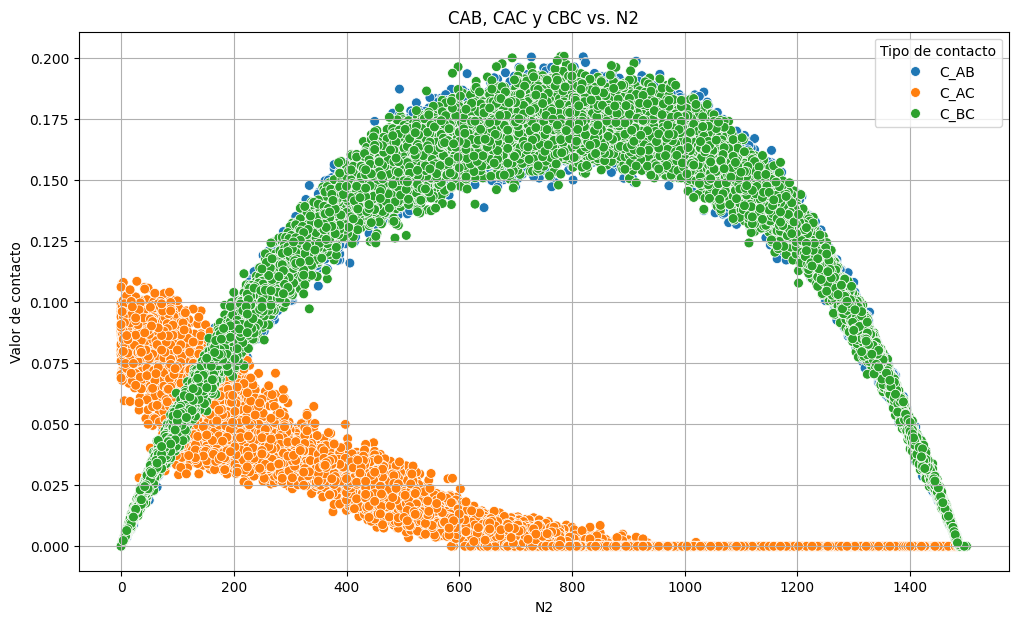

In [6]:
plot_columns = ['C_AB', 'C_AC', 'C_BC']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo_Mean', value_name='Valor_Mean')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor_Mean', hue='Tipo_Mean', data=df_melted, s=50)
plt.title('CAB, CAC y CBC vs. N2')
plt.xlabel('N2')
plt.ylabel('Valor de contacto')
plt.grid(True)
plt.legend(title='Tipo de contacto')
plt.show()

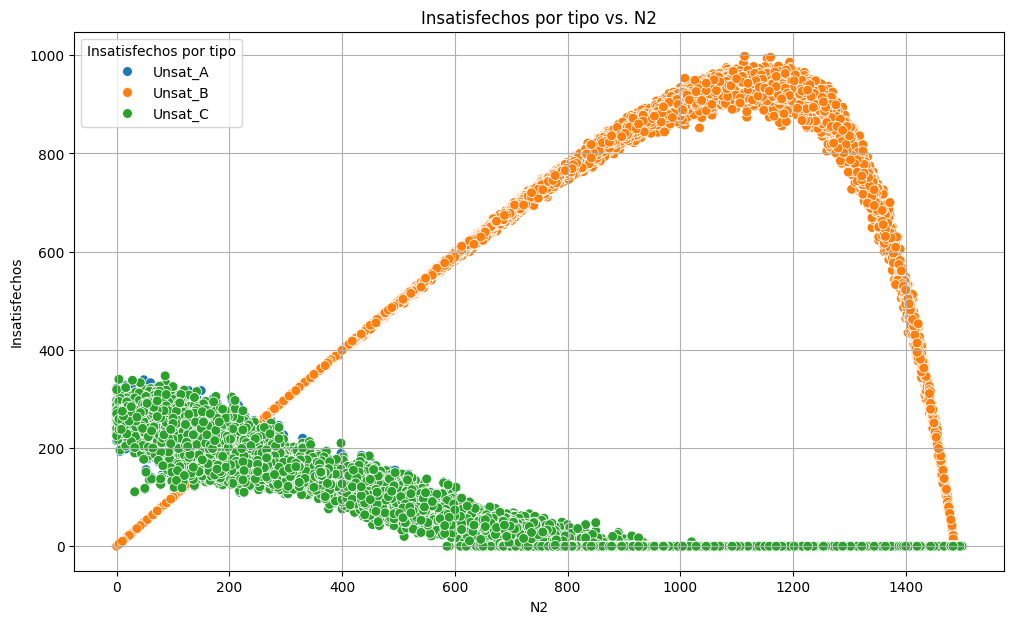

In [7]:
plot_columns = ['Unsat_A', 'Unsat_B', 'Unsat_C']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo', value_name='Valor')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor', hue='Tipo', data=df_melted, s=50)
plt.title('Insatisfechos por tipo vs. N2')
plt.xlabel('N2')
plt.ylabel('Insatisfechos')
plt.grid(True)
plt.legend(title='Insatisfechos por tipo')
plt.show()

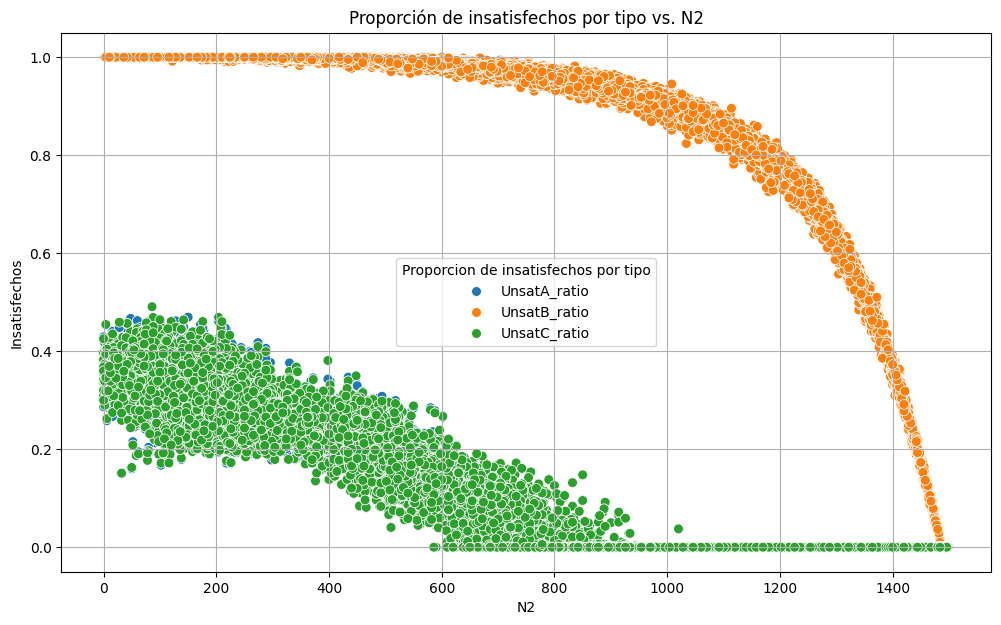

In [8]:
df['UnsatA_ratio'] = df['Unsat_A'] / df['N1']
df['UnsatB_ratio'] = df['Unsat_B'] / df['N2']
df['UnsatC_ratio'] = df['Unsat_C'] / df['N3']

plot_columns = ['UnsatA_ratio', 'UnsatB_ratio', 'UnsatC_ratio']
required_columns = ['N2'] + plot_columns

# Melt el DataFrame para preparar los datos para graficar múltiples series
df_melted = df.melt(id_vars=['N2'], value_vars=plot_columns, var_name='Tipo', value_name='Valor')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='N2', y='Valor', hue='Tipo', data=df_melted, s=50)
plt.title('Proporción de insatisfechos por tipo vs. N2')
plt.xlabel('N2')
plt.ylabel('Insatisfechos')
plt.grid(True)
plt.legend(title='Proporcion de insatisfechos por tipo')
plt.show()

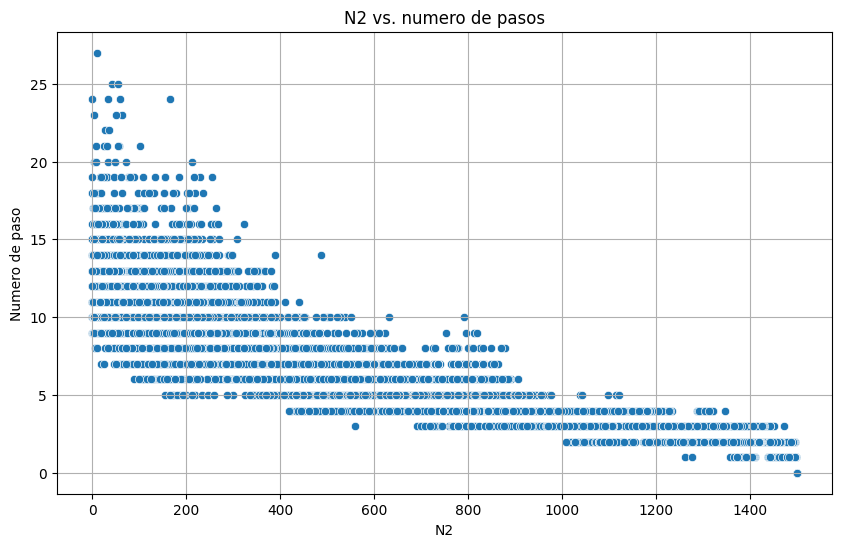

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='N2', y='Steps_to_Equilibrium', data=df)
plt.title('N2 vs. numero de pasos')
plt.xlabel('N2')
plt.ylabel('Numero de paso')
plt.grid(True)
plt.show()

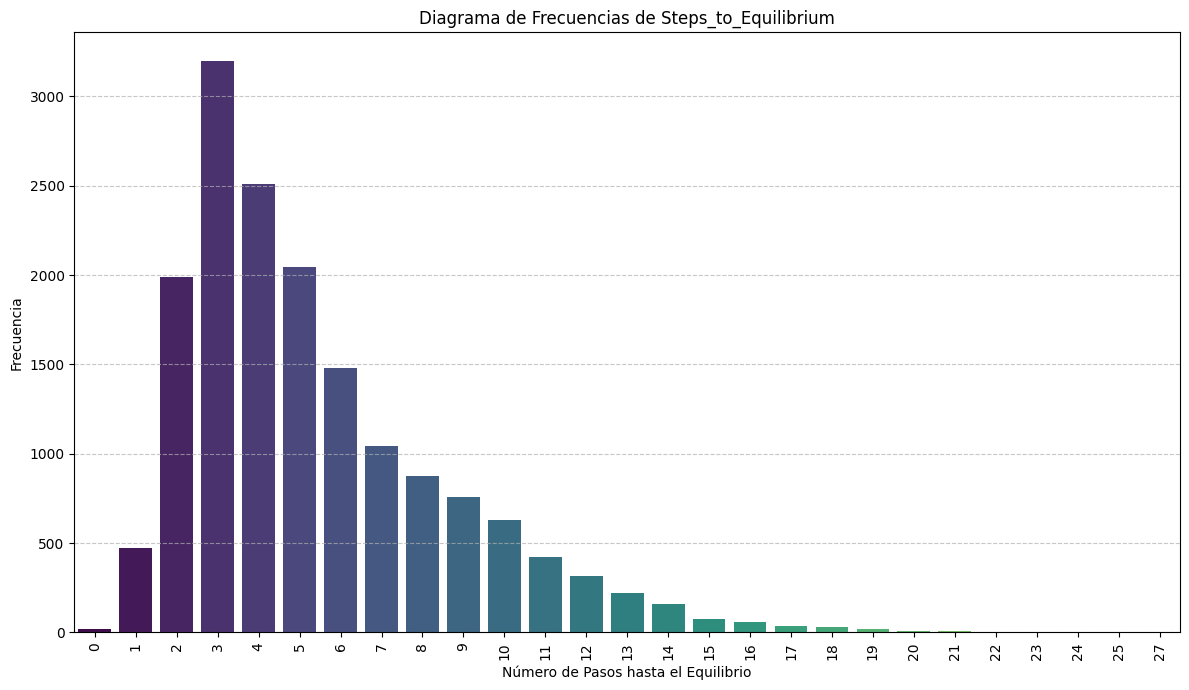

In [10]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Steps_to_Equilibrium', data=df, palette='viridis', hue='Steps_to_Equilibrium', legend=False)
plt.title('Diagrama de Frecuencias de Steps_to_Equilibrium')
plt.xlabel('Número de Pasos hasta el Equilibrio')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90) # Rotate x-axis labels if there are many unique values
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [11]:
import ipywidgets as widgets
from IPython.display import display

# Get min and max N2 values for slider range
n2_min_overall = df['N2'].min()
n2_max_overall = df['N2'].max()

# Create sliders
n2_min_slider = widgets.IntSlider(
    value=n2_min_overall,
    min=n2_min_overall,
    max=n2_max_overall,
    step=1,
    description='N2 Min:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

n2_max_slider = widgets.IntSlider(
    value=n2_max_overall,
    min=n2_min_overall,
    max=n2_max_overall,
    step=1,
    description='N2 Max:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# Define the plotting function
def plot_filtered_frequency(N2min, N2max):
    if N2min > N2max:
        print("N2 Min no puede ser mayor que N2 Max. Ajustando N2 Max a N2 Min.")
        N2max = N2min
        n2_max_slider.value = N2min # Update slider value if invalid

    filtered_df = df[(df['N2'] >= N2min) & (df['N2'] <= N2max)]

    if filtered_df.empty:
        print(f"No hay datos para el rango N2: {N2min}-{N2max}")
        plt.figure(figsize=(12, 7))
        plt.title(f'Diagrama de Frecuencias de Steps_to_Equilibrium (N2: {N2min}-{N2max})')
        plt.xlabel('Número de Pasos hasta el Equilibrio')
        plt.ylabel('Frecuencia')
        plt.grid(True)
        plt.text(0.5, 0.5, 'No hay datos disponibles', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.show()
        return

    plt.figure(figsize=(12, 7))
    sns.countplot(x='Steps_to_Equilibrium', data=filtered_df, palette='viridis', hue='Steps_to_Equilibrium', legend=False)
    plt.title(f'Diagrama de Frecuencias de Steps_to_Equilibrium (N2: {N2min}-{N2max})')
    plt.xlabel('Número de Pasos hasta el Equilibrio')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=90) # Rotate x-axis labels if there are many unique values
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

# Link sliders to the plotting function
widgets.interactive(plot_filtered_frequency, N2min=n2_min_slider, N2max=n2_max_slider)

interactive(children=(IntSlider(value=0, description='N2 Min:', max=1500), IntSlider(value=1500, description='…